<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Streaming fraud — the model and the threshold

*Draft notebook, the narrative view of `src/scoring/train.py`. The consumer scores each transaction and blocks on a **frozen threshold** shipped with the model. Runs two ways from **`MODE`**: `local` trains and scores in-process; `aws` scores through the deployed `fraud-scoring` SageMaker endpoint (the consumer's path). On AWS the threshold travels in `model_meta.json`.*

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters</h2>

Tagged `parameters`: `papermill fraud_scoring.ipynb out.ipynb -p MODE aws` (needs the endpoint up: `make -C aws deploy` / `deploy.py`).

In [1]:
# parameters
MODE = "local"  # "local": train + score in-process  |  "aws": invoke the fraud endpoint
REGION = "us-east-1"
ENDPOINT_NAME = "fraud-scoring"

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

TARGET = "is_fraud"
MIN_PRECISION = (
    0.30  # the block-list must be at least 30% real fraud (train.py --min-precision)
)

with open("../data/feature_spec.json") as f:
    features = json.load(f)["features"]
train_full = pd.read_csv("../data/split/train.csv")
test = pd.read_csv("../data/split/test.csv")

# hold out a calibration slice: the model fits on one part, the threshold is
# tuned on the other -- never on the data the model was fit to.
train_fit, calib = train_test_split(
    train_full, test_size=0.25, stratify=train_full[TARGET], random_state=6
)
f"{len(train_fit):,} fit / {len(calib):,} calibration / {len(test):,} test, fraud rate {train_full[TARGET].mean():.2%}"

'30,000 fit / 10,000 calibration / 10,000 test, fraud rate 0.59%'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the fit / calibration / test split sizes and the overall fraud rate:

```plain
'30,000 fit / 10,000 calibration / 10,000 test, fraud rate 0.59%'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-database" style="color:#18ab4b"></i>&nbsp; The transactions</h2>

In [3]:
train_full[features + [TARGET]].head()

,amount_usd,amount_over_user_avg,seconds_since_last_txn,is_first_merchant,user_txn_count_24h,merchant_fraud_rate,merchant_age_days,is_online,is_night,is_fraud
0,7.93,0.646,9448.0,1,2,0.0000,1308,0,0,0
1,4.89,0.306,5900.0,0,1,0.0017,1132,1,0,0
2,25.81,1.839,53619.0,0,0,0.0000,1034,0,0,0
3,15.40,0.666,36129.0,0,2,0.0000,853,0,0,0
4,82.37,1.795,27461.0,0,2,0.0000,1147,0,0,0


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the first five training rows across the nine model features and the is_fraud label:

```plain
   amount_usd  amount_over_user_avg  seconds_since_last_txn  \
0        7.93                 0.646                  9448.0   
1        4.89                 0.306                  5900.0   
2       25.81                 1.839                 53619.0   
3       15.40                 0.666                 36129.0   
4       82.37                 1.795                 27461.0   

   is_first_merchant  user_txn_count_24h  merchant_fraud_rate  \
0                  1                   2               0.0000   
1                  0                   1               0.0017   
2                  0                   0               0.0000   
3                  0                   2               0.0000   
4                  0                   2               0.0000   

   merchant_age_days  is_online  is_night  is_fraud  
0               1308          0         0         0  
1               1132          1         0         0  
2               1034          0         0         0  
3                853          0         0         0  
4               1147          0         0         0  
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-brain" style="color:#18ab4b"></i>&nbsp; Train — the CatBoost fraud model</h2>

`auto_class_weights="Balanced"` earns its place: at a fraction of a percent fraud, an unweighted model would call everything legit and be ~99.5% accurate and useless. In `aws` mode the model is already trained and served by the endpoint, so this step is skipped.

In [4]:
if MODE == "local":
    from catboost import CatBoostClassifier

    # same fit as src/scoring/train.py
    model = CatBoostClassifier(
        iterations=300, auto_class_weights="Balanced", random_seed=6, verbose=0
    )
    model.fit(train_fit[features], train_fit[TARGET])
    print("model fitted in-process")
else:
    print(f"scoring via endpoint {ENDPOINT_NAME}")

model fitted in-process


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** confirmation that the CatBoost model was fitted in-process under local mode:

```plain
model fitted in-process
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-random" style="color:#18ab4b"></i>&nbsp; One scoring call, two backends</h2>

`score_frame(df)` is the only place the modes differ: in `local` it calls the fitted model; in `aws` it batches the rows to the endpoint and reads back `scores` (the consumer's `invoke_endpoint` contract).

In [5]:
if MODE == "local":

    def score_frame(df):
        """P(fraud) from the in-process model."""
        return model.predict_proba(df[features])[:, 1]
else:
    import boto3

    _runtime = boto3.client("sagemaker-runtime", region_name=REGION)

    def score_frame(df):
        """P(fraud) from the SageMaker endpoint, batched (serve.py returns {'scores': [...]})."""
        records, out = df[features].to_dict("records"), []
        for i in range(0, len(records), 2000):
            resp = _runtime.invoke_endpoint(
                EndpointName=ENDPOINT_NAME,
                ContentType="application/json",
                Body=json.dumps(records[i : i + 2000]),
            )
            out += json.loads(resp["Body"].read())["scores"]
        return np.array(out)


f"scoring backend: {MODE}"

'scoring backend: local'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** which scoring backend the notebook is wired to:

```plain
'scoring backend: local'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-bar" style="color:#18ab4b"></i>&nbsp; Metrics — PR-AUC, not accuracy</h2>

ROC AUC 0.982
PR  AUC 0.586


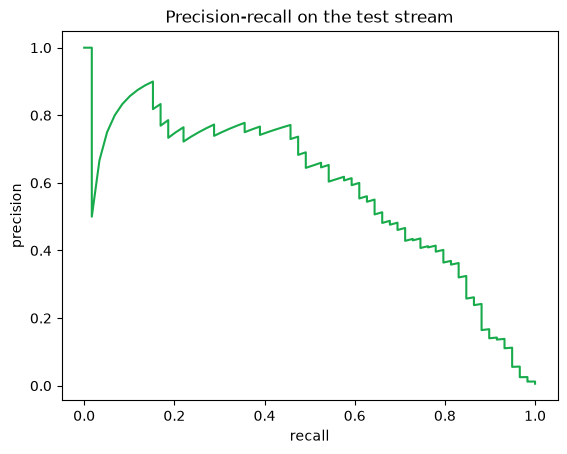

In [6]:
test_scores = score_frame(test)
print(f"ROC AUC {roc_auc_score(test[TARGET], test_scores):.3f}")
print(f"PR  AUC {average_precision_score(test[TARGET], test_scores):.3f}")

prec, rec, _ = precision_recall_curve(test[TARGET], test_scores)
plt.plot(rec, prec, color="#18ab4b")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Precision-recall on the test stream")
plt.show()

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the test-stream ROC AUC and PR AUC printed above the precision-recall curve:

```plain
ROC AUC 0.982
PR  AUC 0.586
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-sliders-h" style="color:#18ab4b"></i>&nbsp; Threshold, first cut — a precision floor</h2>

The chapter's `train.py` picks the threshold on the model's scores over a held-out slice: the smallest score whose precision clears a target, then frozen. Simple, but the 30% is arbitrary.

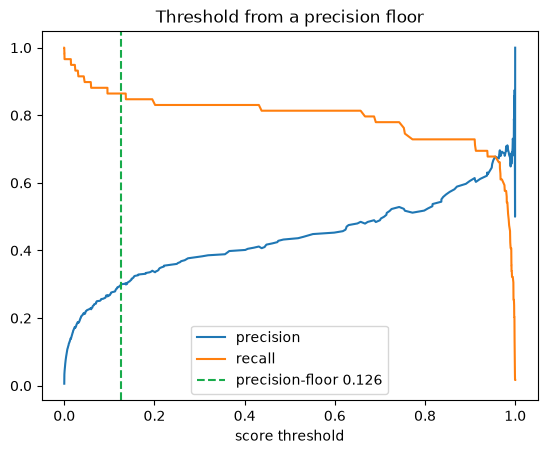

'precision-floor threshold 0.1262 (smallest score with precision >= 30%)'

In [7]:
calib_scores = score_frame(calib)
precision, recall, thresholds = precision_recall_curve(calib[TARGET], calib_scores)
ok = precision[:-1] >= MIN_PRECISION
threshold_p = float(thresholds[ok.argmax()])

plt.plot(thresholds, precision[:-1], label="precision")
plt.plot(thresholds, recall[:-1], label="recall")
plt.axvline(
    threshold_p, color="#18ab4b", ls="--", label=f"precision-floor {threshold_p:.3f}"
)
plt.xlabel("score threshold")
plt.legend()
plt.title("Threshold from a precision floor")
plt.show()
f"precision-floor threshold {threshold_p:.4f} (smallest score with precision >= {MIN_PRECISION:.0%})"

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the precision-floor threshold, the smallest score whose precision clears 30%:

```plain
'precision-floor threshold 0.1262 (smallest score with precision >= 30%)'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-dollar-sign" style="color:#18ab4b"></i>&nbsp; Threshold as a business decision</h2>

Better: give each cell of the confusion matrix a dollar value and pick the threshold that **maximizes expected value** on the held-out calibration slice. Blocking a fraud recovers the prevented loss; missing one costs the amount; blocking a legitimate customer costs friction; processing one earns the fee. (Cost-sensitive thresholding — scikit-learn's `TunedThresholdClassifierCV` idea, as an explicit sweep.)

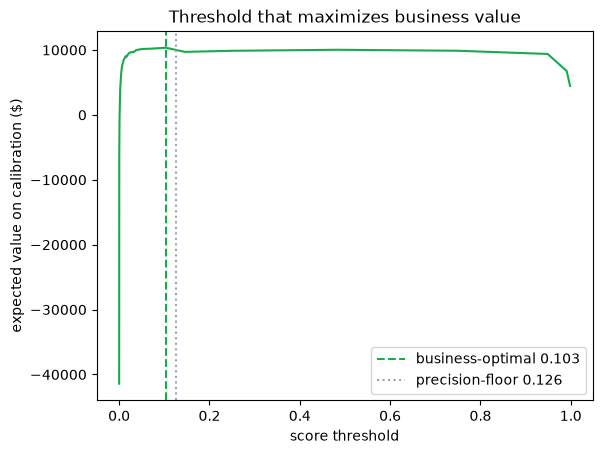

'business-optimal threshold 0.1033'

In [8]:
RECOVERED = 100  # $ prevented loss when a fraud is blocked (true positive)
FRICTION = 10  # $ cost of blocking a legitimate customer (false positive)
FEE_RATE = 0.02  # fee earned on a processed legitimate transaction (true negative)


def business_value(y_true, blocked, amount):
    """Return expected dollars: recovery on caught fraud, minus missed-fraud loss and friction, plus fees."""
    y, amt = y_true.to_numpy(), amount.to_numpy()
    tp, fn = (y == 1) & blocked, (y == 1) & ~blocked
    fp, tn = (y == 0) & blocked, (y == 0) & ~blocked
    return (
        RECOVERED * tp.sum()
        - amt[fn].sum()
        - FRICTION * fp.sum()
        + FEE_RATE * amt[tn].sum()
    )


# sweep candidate thresholds on the CALIBRATION slice, keep the value-maximizing one
grid = np.quantile(calib_scores, np.linspace(0.50, 0.999, 200))
values = [
    business_value(calib[TARGET], calib_scores >= t, calib["amount_usd"]) for t in grid
]
threshold_biz = float(grid[int(np.argmax(values))])

plt.plot(grid, values, color="#18ab4b")
plt.axvline(
    threshold_biz,
    color="#18ab4b",
    ls="--",
    label=f"business-optimal {threshold_biz:.3f}",
)
plt.axvline(
    threshold_p, color="#94a3b8", ls=":", label=f"precision-floor {threshold_p:.3f}"
)
plt.xlabel("score threshold")
plt.ylabel("expected value on calibration ($)")
plt.legend()
plt.title("Threshold that maximizes business value")
plt.show()
f"business-optimal threshold {threshold_biz:.4f}"

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the business-optimal threshold that maximizes expected dollar value on the calibration slice:

```plain
'business-optimal threshold 0.1033'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-clipboard-check" style="color:#18ab4b"></i>&nbsp; The two thresholds, on the test stream</h2>

In [9]:
def report(thr):
    """Score the block at one threshold: blocked count, recall, precision, business value."""
    blocked = test_scores >= thr
    frauds = int((test[TARGET] == 1).sum())
    caught = int((blocked & (test[TARGET] == 1)).sum())
    return {
        "threshold": round(thr, 4),
        "blocked": int(blocked.sum()),
        "recall": f"{caught / frauds:.1%}",
        "precision": f"{caught / max(int(blocked.sum()), 1):.1%}",
        "business value ($)": round(
            business_value(test[TARGET], blocked, test["amount_usd"])
        ),
    }


pd.DataFrame(
    {"precision floor": report(threshold_p), "business value": report(threshold_biz)}
).T

,threshold,blocked,recall,precision,business value ($)
precision floor,0.1262,140,83.1%,35.0%,10750
business value,0.1033,152,83.1%,32.2%,10600


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** a two-row table comparing the precision-floor and business-value thresholds on the test stream:

```plain
                threshold blocked recall precision business value ($)
precision floor    0.1262     140  83.1%     35.0%              10750
business value     0.1033     152  83.1%     32.2%              10600
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-play-circle" style="color:#18ab4b"></i>&nbsp; Score one transaction</h2>

In [10]:
threshold = threshold_biz  # the threshold shipped in model_meta.json
txn = test[test[TARGET] == 1].iloc[[0]]  # a real fraud from the test stream
score = float(score_frame(txn)[0])
display(txn[features])
f"score {score:.4f} vs threshold {threshold:.4f} -> {'BLOCK' if score >= threshold else 'ALLOW'}"

,amount_usd,amount_over_user_avg,seconds_since_last_txn,is_first_merchant,user_txn_count_24h,merchant_fraud_rate,merchant_age_days,is_online,is_night
28,95.19,2.051,32036.0,0,2,0.2697,2989,1,0


'score 0.9997 vs threshold 0.1033 -> BLOCK'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the feature row for one real fraud and its score against the shipped threshold, which blocks it:

```plain
    amount_usd  amount_over_user_avg  seconds_since_last_txn  \
28       95.19                 2.051                 32036.0   

    is_first_merchant  user_txn_count_24h  merchant_fraud_rate  \
28                  0                   2               0.2697   

    merchant_age_days  is_online  is_night  
28               2989          1         0  

'score 0.9997 vs threshold 0.1033 -> BLOCK'
```

---
*`MODE="aws"` scores this same notebook through the deployed `fraud-scoring` endpoint; the streaming consumer (`src/streaming/consumer.py`) makes the identical `invoke_endpoint` call. See `aws/`.*